#인공지능개론 5주차 과제

###컴퓨터공학과 202337644 김태규
---

데이터 준비 단계

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# 데이터 로드
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/breast_cancer.csv', index_col=0)
df = df.dropna()



- X - 특성 -> 입력 데이터
- y - 예측 대상 -> 정답

In [4]:
X = df.drop('mean radius', axis=1).values
y = df['mean radius'].values



80% 학습용, 20% 테스트용

In [5]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)



스케일링 중요!<br>
딥러닝은 값 크기가 제각각이면 학습이 잘 안됨

In [6]:
scaler = StandardScaler() # 데이터 크기 맞추기 정규화
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 68.3357 - mae: 6.4838 - val_loss: 16.3205 - val_mae: 3.3266
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 16.6872 - mae: 3.2452 - val_loss: 9.9453 - val_mae: 2.3762
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.8170 - mae: 2.4393 - val_loss: 7.6447 - val_mae: 2.0293
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.6167 - mae: 1.8230 - val_loss: 4.8628 - val_mae: 1.7157
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.6516 - mae: 1.4807 - val_loss: 5.2919 - val_mae: 1.6246
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.5260 - mae: 1.2494 - val_loss: 3.0290 - val_mae: 1.2956
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6939 - mae: 1.0287 - val_loss: 2.4774 - val_mae: 1.1363
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.1849 - mae: 0.8727 - val_loss: 2.1860 - val_mae: 1.0435
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9045 - mae: 0.7616 

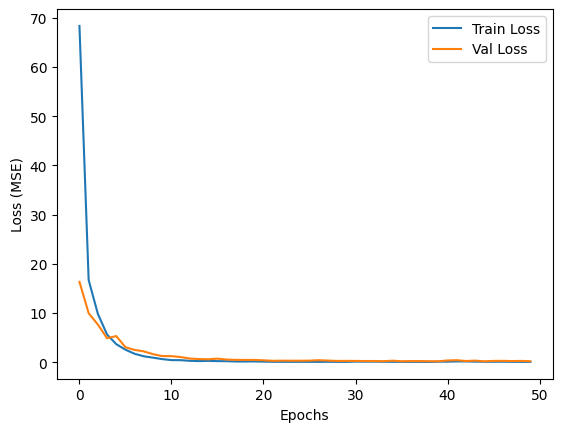

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


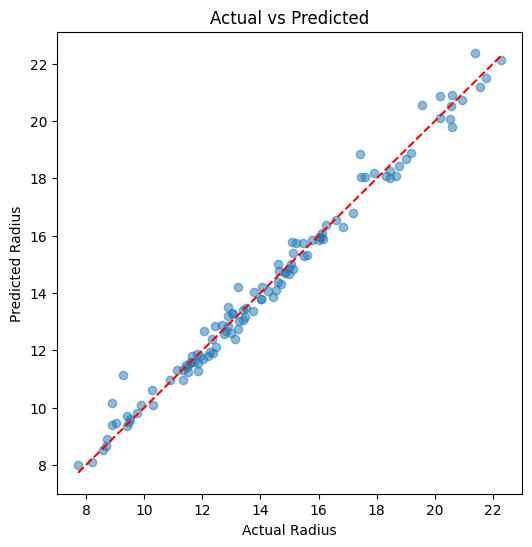

Final RMSE: 0.4304


In [7]:
# 회귀 딥러닝 모델 설계
model = Sequential([
    Dense(64, input_shape=(X_train.shape[1],), activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1) # 회귀 모델의 마지막 출력층은 활성화 함수 없이 노드 1개
])

# 컴파일
model.compile(optimizer=Adam(learning_rate=0.01), loss='mse', metrics=['mae'])

# 모델 학습
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# 학습 결과 시각화 (Loss 확인)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

# 실제값 vs 예측값 비교 시각화
y_pred = model.predict(X_test).flatten()

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # 기준선
plt.xlabel('Actual Radius')
plt.ylabel('Predicted Radius')
plt.title('Actual vs Predicted')
plt.show()

# 오차 지표 확인
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Final RMSE: {rmse:.4f}")